<a href="https://colab.research.google.com/github/dee1303/btc-price-monitoring-pipeline/blob/main/Deepti_MAKE_A_COPY_Homework_SQL_Fall_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTANT!
Make sure to copy this document to your google drive before starting to modify it, as shown in the image below.

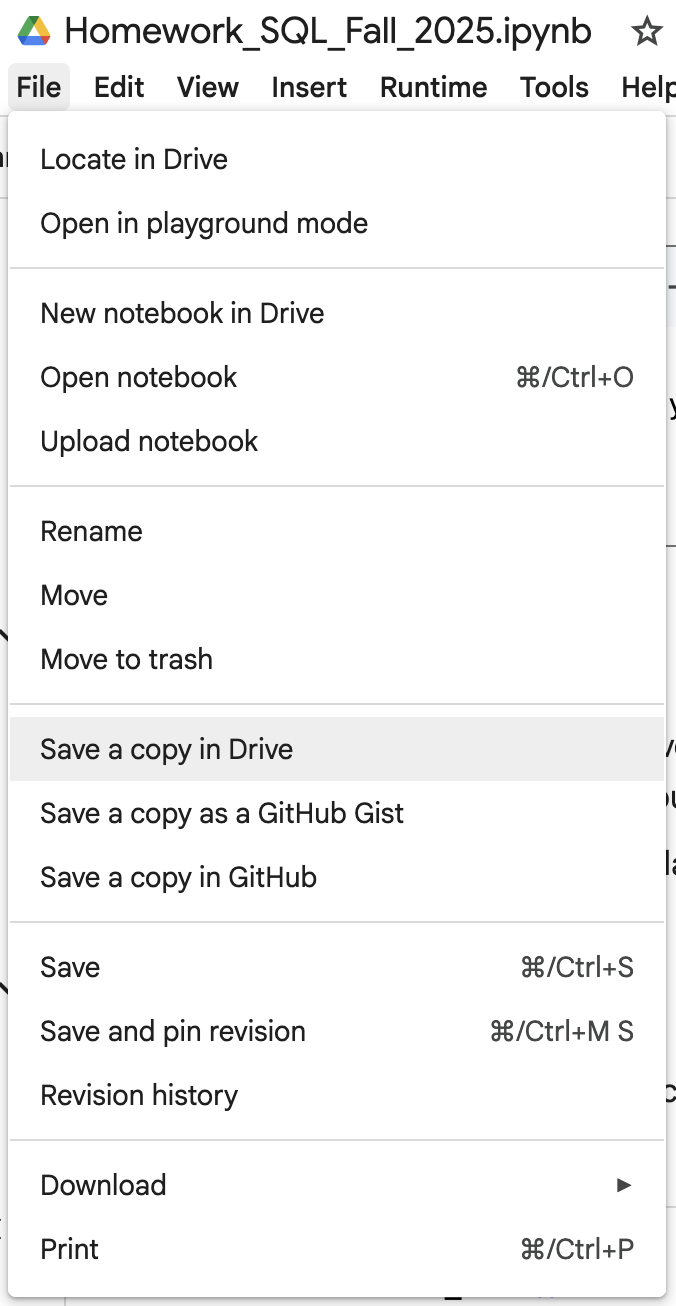

# Homework: SQL

In this homework you'll put to practice everything we'll seen so far.
Feel free to review the material from the sessions, including the SQL tutorials linked or any other internet resource you've been using to learn.

The goal is to start answering business data questions using SQL.


## Connecting to Biq Query
In the next two cells, we'll configure the connection to Big Query. No need to modify anything in this section, just run the cells and move on.

In [40]:
from google.colab import auth
auth.authenticate_user()

In [42]:
from google.cloud import bigquery
client = bigquery.Client(project='redi-da25')

## Exercises
In the next sections, you'll need to write a SQL that answers the corresponding business questions.

### 1.- Find the details of all products  that haven't been sold yet.
Hint: You'll need to join 2 tables to get the result.

The commands to execute the query are already written below. Just replace the text `TODO: write the query here` with the SQL.

In [16]:


sql_query = '''

SELECT
  prod.product_id
FROM SQL_Practice.products AS prod
LEFT JOIN SQL_Practice.orders AS ord
  ON ord.product_id = ord.product_id
WHERE
  ord.order_id IS NULL

'''

df = client.query(sql_query).to_dataframe()
df

,product_id


In [55]:
from google.cloud import bigquery
client = bigquery.Client(project='redi-da25')

### 2.- Find the 10 best selling products by sales
Hint: You'll need to return the names of the products along with the total sold in the correct order.

In [66]:
#highest items sales
#if we make it sum( price and quantity ) will get most of the items  sold on which products
sql_query = ('''
select  a.product_id , a.product_name ,sum(b.quantity) as total_sales
from `SQL_Practice.products` a inner join `SQL_Practice.orders` b
on a.product_id = b.product_id
group by a.product_id,a.product_name
order by total_sales Desc
 limit 10
             ''')
df = client.query(sql_query).to_dataframe()
df


,product_id,product_name,total_sales
0,P055,Monitor 55,201
1,P060,Wireless Mouse 60,193
2,P018,Bluetooth Speaker 18,191
3,P065,USB Cable 65,178
4,P071,Water Bottle 71,178
5,P067,Face Cream 67,178
6,P048,Yoga Mat 48,177
7,P006,Vacuum Cleaner 6,177
8,P023,Jacket 23,176
9,P059,Perfume 59,175


### 3.- Find the top customer
Hint: most products are coming from this customer.


In [62]:
# @title
sql_query = ('''
SELECT c.customer_id ,
sum(p.price * o.quantity) as total_sales
FROM SQL_Practice.products AS p
INNER JOIN SQL_Practice.orders AS o
  ON p.product_id = o.product_id
INNER JOIN SQL_Practice.customers AS c
  ON o.customer_id = c.customer_id
 GROUP BY
 c.customer_id
 ORDER BY total_sales DESC
LIMIT 1

''')

df = client.query(sql_query).to_dataframe()
df

,customer_id,total_sales
0,C0299,5124.21


### 4. Find Top 3 product categories by amount of orders
Hint: users from these countries place most of the orders.

In [63]:
# TODO: create and execute the SQL
sql_query = ('''

select p.category,count(o.order_id) as amt_of_orders
FROM SQL_Practice.products AS p
INNER JOIN SQL_Practice.orders AS o
  ON p.product_id = o.product_id
INNER JOIN SQL_Practice.customers AS c
  ON o.customer_id = c.customer_id
 GROUP BY p.category
 ORDER BY amt_of_orders DESC
  LIMIT 3

 ''')


df = client.query(sql_query).to_dataframe()
df

,category,amt_of_orders
0,Sports,1077
1,Home,1033
2,Clothing,722


### 5.- Total customers per city as well as totals per gender
Hint: you will need to return all 3 totals per row: total_customers, total_f, total_m.

In [64]:
# TODO: create and execute the SQL
sql_query=('''

select count(customer_id) as total_customers,

 count(
 case when gender = 'Male' then c.customer_id else null end
  ) as  total_Male_gender_customer,
  count( case
  when gender = 'Female' then c.customer_id else null End ) as  total_Female_gender_customer

   from

SQL_Practice.customers AS c

 GROUP BY  city

''')
df = client.query(sql_query).to_dataframe()
df

,total_customers,total_Male_gender_customer,total_Female_gender_customer
0,159,71,88
1,156,81,75
2,146,78,68
3,137,77,60
4,146,70,76
5,133,71,62
6,160,76,84
7,163,89,74


### 6.- Bonus points: Find the top 5 order months by sales (focus on payment_method Online)
Hint: You might need to join 3 tables.


In [65]:
# TODO: create and execute the SQL
sql_query=('''

select  extract (month from order_date) as Date_month  ,
count(order_id) as no_of_sales
FROM SQL_Practice.orders AS o
where o.payment_method ='Online'
group by all
order by no_of_sales desc
limit 5
''')
df = client.query(sql_query).to_dataframe()
df

,Date_month,no_of_sales
0,3,180
1,1,169
2,2,151
3,4,139
4,5,128
